In [12]:
import os
import splitfolders
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
RAW_DATA_DIR   = "Data"           # your original dataset folder
SPLIT_DATA_DIR = "/teamspace/studios/this_studio/Data_split"     # where train/val/test will be saved

# # ── Split ratios (must sum to 1.0) ─────────────────────
# TRAIN_RATIO = 0.70
# VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15

# ── Training ───────────────────────────────────────────
NUM_CLASSES    = 4
BATCH_SIZE     = 16
NUM_EPOCHS     = 20
LEARNING_RATE  = 0.00001
IMAGE_SIZE     = 224          # AlexNet expects 224x224

# ── Output ─────────────────────────────────────────────
MODEL_SAVE_PATH = "alexnet_alzheimer.pth"

In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DATA_DIR, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(SPLIT_DATA_DIR, "val"),   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(SPLIT_DATA_DIR, "test"),  transform=val_test_transforms)

class_names = train_dataset.classes
print("Classes:", class_names)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Train: 60504 | Val: 12964 | Test: 12969


In [15]:


splits = ["train", "val", "test"]
for split in splits:
    print(f"\n=== {split.upper()} ===")
    split_path = os.path.join(SPLIT_DATA_DIR, split)
    total = 0
    for cls in sorted(os.listdir(split_path)):
        count = len(os.listdir(os.path.join(split_path, cls)))
        total += count
        print(f"  {cls:<25}: {count} images")
    print(f"  {'TOTAL':<25}: {total} images")


=== TRAIN ===
  Mild Dementia            : 3501 images
  Moderate Dementia        : 341 images
  Non Demented             : 47055 images
  Very mild Dementia       : 9607 images
  TOTAL                    : 60504 images

=== VAL ===
  Mild Dementia            : 750 images
  Moderate Dementia        : 73 images
  Non Demented             : 10083 images
  Very mild Dementia       : 2058 images
  TOTAL                    : 12964 images

=== TEST ===
  Mild Dementia            : 751 images
  Moderate Dementia        : 74 images
  Non Demented             : 10084 images
  Very mild Dementia       : 2060 images
  TOTAL                    : 12969 images


In [17]:
print(torch.cuda.is_available())        # True = GPU ready
print(torch.cuda.get_device_name(0))    # Should print: Tesla T4

True
Tesla T4


In [16]:
from torch.utils.data import WeightedRandomSampler

# Step 1: Count samples per class
class_counts = np.zeros(NUM_CLASSES)
for _, label in train_dataset:
    class_counts[label] += 1

print("Training samples per class:")
for cls, cnt in zip(class_names, class_counts):
    print(f"  {cls:<25}: {int(cnt)}")

# Step 2: Compute inverse frequency weights
class_weights = 1.0 / class_counts
print("\nClass weights:")
for cls, w in zip(class_names, class_weights):
    print(f"  {cls:<25}: {w:.6f}")

# Step 3: Assign weight to every sample
sample_weights = torch.FloatTensor([class_weights[label] for _, label in train_dataset])

# Step 4: Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

# Step 5: Rebuild loaders — shuffle=False because sampler handles it
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)

print("\nWeighted sampler applied ✅")

Training samples per class:
  Mild Dementia            : 3501
  Moderate Dementia        : 341
  Non Demented             : 47055
  Very mild Dementia       : 9607

Class weights:
  Mild Dementia            : 0.000286
  Moderate Dementia        : 0.002933
  Non Demented             : 0.000021
  Very mild Dementia       : 0.000104

Weighted sampler applied ✅


In [18]:
images, labels = next(iter(train_loader))
unique, counts = np.unique(labels.numpy(), return_counts=True)

print("Class distribution in one batch (should see all 4 classes):")
for cls, cnt in zip(unique, counts):
    print(f"  {class_names[cls]:<25}: {cnt} samples")

Class distribution in one batch (should see all 4 classes):
  Mild Dementia            : 3 samples
  Moderate Dementia        : 4 samples
  Non Demented             : 4 samples
  Very mild Dementia       : 5 samples


In [19]:
def build_alexnet(num_classes):
    model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)  # loads ImageNet pretrained weights
    model.classifier[6] = nn.Linear(4096, num_classes)              # replace last layer for 4 classes
    return model

model = build_alexnet(NUM_CLASSES).to(device)
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [20]:
# Freeze all layers except the classifier
for param in model.features.parameters():
    param.requires_grad = False

print("Feature layers frozen ✅")
print("Only classifier head will train for first 5 epochs") 

Feature layers frozen ✅
Only classifier head will train for first 5 epochs


In [21]:
from sklearn.metrics import f1_score

class_weights_tensor = torch.FloatTensor(class_weights / class_weights.sum() * NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "val_loss": [],
           "train_acc":  [], "val_acc":  [],
           "train_f1":   [], "val_f1":   []}

print("Loss and Optimizer ready ✅")

Loss and Optimizer ready ✅


In [22]:
for epoch in range(NUM_EPOCHS):

    # Unfreeze all layers after epoch 5
    if epoch == 5:
        for param in model.features.parameters():
            param.requires_grad = True
        print("\n>>> All layers unfrozen from epoch 6 onwards <<<\n")

    # ── Train ──────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0
    train_preds_all, train_labels_all = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_preds_all.extend(outputs.argmax(1).cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

    # ── Validate ───────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0
    val_preds_all, val_labels_all = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_preds_all.extend(outputs.argmax(1).cpu().numpy())
            val_labels_all.extend(labels.cpu().numpy())

    # ── Compute metrics ────────────────────────────────
    t_loss = train_loss / len(train_dataset)
    v_loss = val_loss   / len(val_dataset)
    t_acc  = train_correct / len(train_dataset) * 100
    v_acc  = val_correct   / len(val_dataset)   * 100
    t_f1   = f1_score(train_labels_all, train_preds_all, average='macro') * 100
    v_f1   = f1_score(val_labels_all,   val_preds_all,   average='macro') * 100

    # ── Store history ──────────────────────────────────
    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)
    history["train_f1"].append(t_f1)
    history["val_f1"].append(v_f1)

    # ── Print epoch summary ────────────────────────────
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}]")
    print(f"  Train  →  Loss: {t_loss:.4f}  Acc: {t_acc:.2f}%  F1: {t_f1:.2f}%")
    print(f"  Val    →  Loss: {v_loss:.4f}  Acc: {v_acc:.2f}%  F1: {v_f1:.2f}%")
    print("-" * 60)


Epoch [01/20]
  Train  →  Loss: 0.3239  Acc: 44.11%  F1: 38.40%
  Val    →  Loss: 1.7277  Acc: 40.37%  F1: 27.70%
------------------------------------------------------------
Epoch [02/20]
  Train  →  Loss: 0.1847  Acc: 60.66%  F1: 57.60%
  Val    →  Loss: 1.6382  Acc: 42.71%  F1: 31.41%
------------------------------------------------------------
Epoch [03/20]
  Train  →  Loss: 0.1462  Acc: 66.39%  F1: 64.13%
  Val    →  Loss: 1.4331  Acc: 47.86%  F1: 39.53%
------------------------------------------------------------
Epoch [04/20]
  Train  →  Loss: 0.1275  Acc: 69.31%  F1: 67.60%
  Val    →  Loss: 1.2800  Acc: 52.99%  F1: 40.50%
------------------------------------------------------------
Epoch [05/20]
  Train  →  Loss: 0.1108  Acc: 71.53%  F1: 70.05%
  Val    →  Loss: 1.3999  Acc: 51.57%  F1: 39.58%
------------------------------------------------------------

>>> All layers unfrozen from epoch 6 onwards <<<

Epoch [06/20]
  Train  →  Loss: 0.0904  Acc: 75.12%  F1: 73.95%
  Val    →

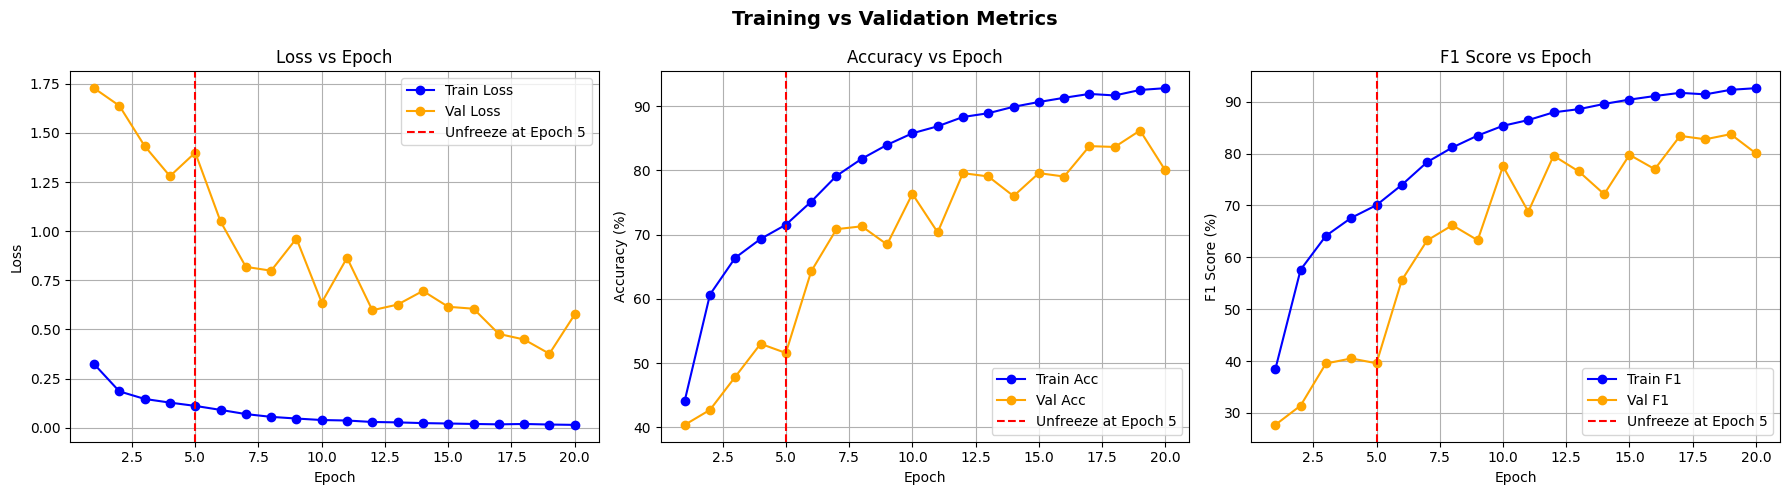

In [23]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# ── Loss ──────────────────────────────────────────────
ax1.plot(epochs, history["train_loss"], label="Train Loss", marker="o", color="blue")
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   marker="o", color="orange")
ax1.axvline(x=5, color="red", linestyle="--", label="Unfreeze at Epoch 5")
ax1.set_title("Loss vs Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# ── Accuracy ───────────────────────────────────────────
ax2.plot(epochs, history["train_acc"], label="Train Acc", marker="o", color="blue")
ax2.plot(epochs, history["val_acc"],   label="Val Acc",   marker="o", color="orange")
ax2.axvline(x=5, color="red", linestyle="--", label="Unfreeze at Epoch 5")
ax2.set_title("Accuracy vs Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

# ── F1 Score ───────────────────────────────────────────
ax3.plot(epochs, history["train_f1"], label="Train F1", marker="o", color="blue")
ax3.plot(epochs, history["val_f1"],   label="Val F1",   marker="o", color="orange")
ax3.axvline(x=5, color="red", linestyle="--", label="Unfreeze at Epoch 5")
ax3.set_title("F1 Score vs Epoch")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("F1 Score (%)")
ax3.legend()
ax3.grid(True)

plt.suptitle("Training vs Validation Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [25]:
# Model is already in memory from training — no need to load from disk
# Just set to evaluation mode directly
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("✅ Inference on test set complete")
print(f"Total test images: {len(all_labels)}")

✅ Inference on test set complete
Total test images: 12969


In [26]:
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             cohen_kappa_score, matthews_corrcoef)

acc     = accuracy_score(all_labels, all_preds) * 100
f1      = f1_score(all_labels, all_preds, average='macro') * 100
prec    = precision_score(all_labels, all_preds, average='macro') * 100
rec     = recall_score(all_labels, all_preds, average='macro') * 100
kappa   = cohen_kappa_score(all_labels, all_preds)
mcc     = matthews_corrcoef(all_labels, all_preds)

print("=" * 50)
print("        TEST SET EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy          : {acc:.2f}%")
print(f"  F1 Score (macro)  : {f1:.2f}%")
print(f"  Precision (macro) : {prec:.2f}%")
print(f"  Recall (macro)    : {rec:.2f}%")
print(f"  Cohen Kappa       : {kappa:.4f}")
print(f"  MCC               : {mcc:.4f}")
print("=" * 50)

        TEST SET EVALUATION RESULTS
  Accuracy          : 79.67%
  F1 Score (macro)  : 79.90%
  Precision (macro) : 74.08%
  Recall (macro)    : 93.38%
  Cohen Kappa       : 0.5896
  MCC               : 0.6490


In [27]:
from sklearn.metrics import classification_report

print("PER CLASS REPORT")
print("=" * 50)
print(classification_report(all_labels, all_preds,
                             target_names=class_names))

PER CLASS REPORT
                    precision    recall  f1-score   support

     Mild Dementia       0.66      1.00      0.80       751
 Moderate Dementia       0.82      1.00      0.90        74
      Non Demented       1.00      0.74      0.85     10084
Very mild Dementia       0.48      1.00      0.65      2060

          accuracy                           0.80     12969
         macro avg       0.74      0.93      0.80     12969
      weighted avg       0.90      0.80      0.81     12969



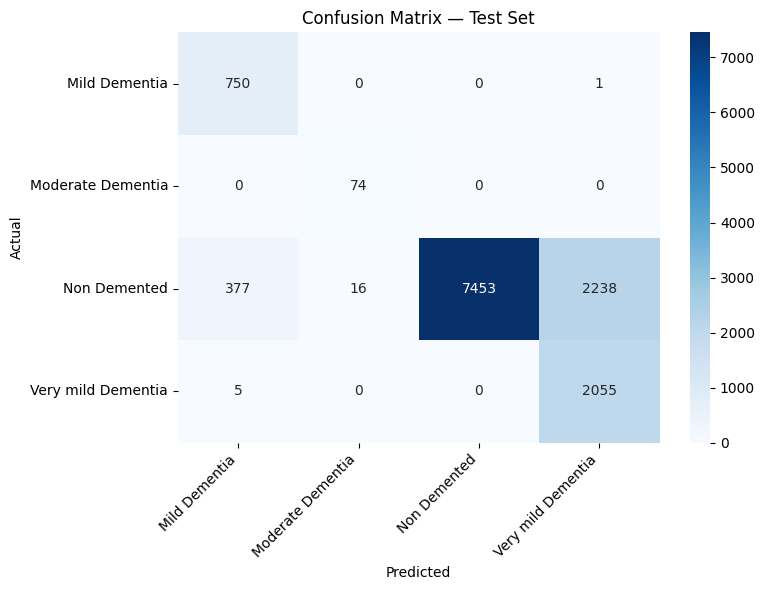

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [31]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

Model saved to: alexnet_alzheimer.pth
